# WEEK -08: K-Nearest Neighbour (K-NN) & ID-3 Decision Tree

In [22]:
import csv
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

1A.
<br>You are provided with a dataset of fruits. Each fruit is characterized by two features: weight (in grams) and
sweetness level (on a scale of 1 to 10). You want to classify a new fruit as either an "Apple" or an "Orange"
based on these features using the KNN algorithm.
Fruit ID Weight (grams) Sweetness Level Label (Fruit Type)<br>

Tasks:<br>
<br>1. Implement the KNN algorithm manually with k=3 to classify a new fruit with a weight of 165 grams
and sweetness level of 5.5.
<br>2. Calculate the Euclidean, Manhattan, and Minkowski distances between the new fruit and all the
existing fruits in the dataset. Finally compare the calculated distances.
<br>3. Based on the k-nearest neighbors, determine the label for the new fruit.
<br>4. What is the effect of choosing different values of k (e.g., k=1, k=5) on the classification result?
<br>5. Implement the above using function python program without using scikit learn library.
<br>6. Plot the given samples, the Apple in Red color and the Orange in orange color. Also draw the
decision boundary.

KNN FRUIT CLASSIFICATION

New fruit: Weight = 165 grams, Sweetness = 5.5

DISTANCES FROM NEW FRUIT
----------------------------------------------------------------------------------------------------
ID   Weight      Sweetness   Label       Euclidean      Manhattan      Minkowski(p=3)    
----------------------------------------------------------------------------------------------------
1    180.00      7.00        Apple       15.0748        16.5000        15.0050           
2    200.00      6.00        Apple       35.0036        35.5000        35.0000           
3    150.00      4.00        Orange      15.0748        16.5000        15.0050           
4    170.00      5.00        Orange      5.0249         5.5000         5.0017            
5    160.00      6.00        Apple       5.0249         5.5000         5.0017            
6    140.00      3.00        Orange      25.1247        27.5000        25.0083           

K = 3

3 Nearest Neighbors:
1. Fruit ID = 4, Distance = 5.0249, Labe

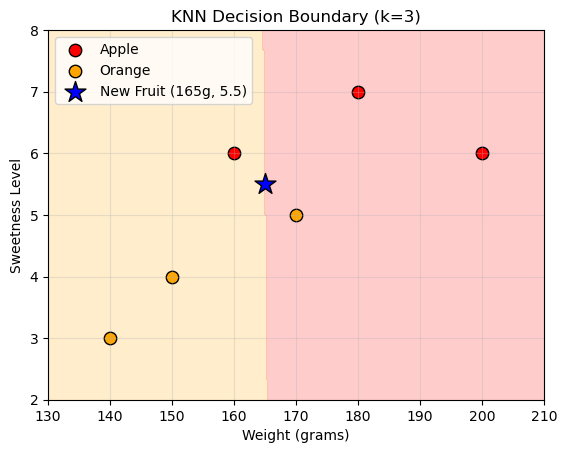

In [15]:
def load_data(filename):
    weights = []
    sweetness = []
    labels = []

    with open(filename, "r", newline="") as file:
        reader = csv.DictReader(file)

        for row in reader:
            weights.append(float(row["Weight (grams)"]))
            sweetness.append(float(row["Sweetness Level"]))
            labels.append(row["Label (Fruit Type)"].strip())

    return np.array(weights), np.array(sweetness), np.array(labels)


# 2. Distance functions

def euclidean_distance(point1, point2):
    return math.sqrt(
        (point1[0] - point2[0]) ** 2 +
        (point1[1] - point2[1]) ** 2
    )


def manhattan_distance(point1, point2):
    return (
        abs(point1[0] - point2[0]) +
        abs(point1[1] - point2[1])
    )


def minkowski_distance(point1, point2, p=3):
    return (
        abs(point1[0] - point2[0]) ** p +
        abs(point1[1] - point2[1]) ** p
    ) ** (1 / p)


# 3. Calculate all distances

def calculate_distances(weights, sweetness, labels, new_fruit):
    results = []

    for i in range(len(weights)):
        fruit = (weights[i], sweetness[i])

        euclidean = euclidean_distance(new_fruit, fruit)
        manhattan = manhattan_distance(new_fruit, fruit)
        minkowski = minkowski_distance(new_fruit, fruit, p=3)

        results.append({
            "id": i + 1,
            "weight": weights[i],
            "sweetness": sweetness[i],
            "label": labels[i],
            "euclidean": euclidean,
            "manhattan": manhattan,
            "minkowski": minkowski
        })

    return results

# 4. Manual KNN algorithm

def knn_predict(weights, sweetness, labels, new_fruit, k=3):
    distances = []

    for i in range(len(weights)):
        fruit = (weights[i], sweetness[i])

        distance = euclidean_distance(new_fruit, fruit)

        distances.append(
            (distance, labels[i], i)
        )

    distances.sort(key=lambda x: x[0])
    neighbors = distances[:k]

    # Count votes
    votes = {}

    for distance, label, index in neighbors:
        votes[label] = votes.get(label, 0) + 1

    # Select class with maximum votes
    prediction = max(votes, key=votes.get)

    return prediction, neighbors, votes


# ---------------------------------------------------------
# 5. Print distance table
# ---------------------------------------------------------

def print_distance_table(results):
    print("\nDISTANCES FROM NEW FRUIT")
    print("-" * 100)

    print(
        f"{'ID':<5}"
        f"{'Weight':<12}"
        f"{'Sweetness':<12}"
        f"{'Label':<12}"
        f"{'Euclidean':<15}"
        f"{'Manhattan':<15}"
        f"{'Minkowski(p=3)':<18}"
    )

    print("-" * 100)

    for r in results:
        print(
            f"{r['id']:<5}"
            f"{r['weight']:<12.2f}"
            f"{r['sweetness']:<12.2f}"
            f"{r['label']:<12}"
            f"{r['euclidean']:<15.4f}"
            f"{r['manhattan']:<15.4f}"
            f"{r['minkowski']:<18.4f}"
        )


# ---------------------------------------------------------
# 6. Plot samples and decision boundary
# ---------------------------------------------------------

def plot_knn_boundary(weights, sweetness, labels, k=3):

    # Convert labels to numeric classes
    unique_labels = np.unique(labels)

    # Create a grid
    weight_min = weights.min() - 10
    weight_max = weights.max() + 10

    sweet_min = sweetness.min() - 1
    sweet_max = sweetness.max() + 1

    xx, yy = np.meshgrid(
        np.linspace(weight_min, weight_max, 300),
        np.linspace(sweet_min, sweet_max, 300)
    )

    # Predict class at each grid point
    Z = []

    for y in np.linspace(sweet_min, sweet_max, 300):
        row = []

        for x in np.linspace(weight_min, weight_max, 300):
            prediction, _, _ = knn_predict(
                weights,
                sweetness,
                labels,
                (x, y),
                k=k
            )

            row.append(
                0 if prediction == unique_labels[0] else 1
            )

        Z.append(row)

    Z = np.array(Z)

    # Decision regions
    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.20,
        levels=[-0.5, 0.5, 1.5],
        colors=["red", "orange"]
    )

    # Plot fruits
    apple_mask = labels == "Apple"
    orange_mask = labels == "Orange"

    plt.scatter(
        weights[apple_mask],
        sweetness[apple_mask],
        color="red",
        edgecolor="black",
        s=80,
        label="Apple"
    )

    plt.scatter(
        weights[orange_mask],
        sweetness[orange_mask],
        color="orange",
        edgecolor="black",
        s=80,
        label="Orange"
    )

    # New fruit
    new_weight = 165
    new_sweetness = 5.5

    plt.scatter(
        new_weight,
        new_sweetness,
        color="blue",
        marker="*",
        s=250,
        edgecolor="black",
        label="New Fruit (165g, 5.5)"
    )

    plt.xlabel("Weight (grams)")
    plt.ylabel("Sweetness Level")
    plt.title(f"KNN Decision Boundary (k={k})")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


# ---------------------------------------------------------
# 7. Main program
# ---------------------------------------------------------

def main():

    # Load fruits.csv
    weights, sweetness, labels = load_data("fruits.csv")

    # New fruit
    new_fruit = (165, 5.5)

    print("KNN FRUIT CLASSIFICATION")

    print(
        f"\nNew fruit: Weight = {new_fruit[0]} grams, "
        f"Sweetness = {new_fruit[1]}"
    )

    # ---------------------------------------------
    # Calculate distances
    # ---------------------------------------------

    results = calculate_distances(
        weights,
        sweetness,
        labels,
        new_fruit
    )

    print_distance_table(results)

    # ---------------------------------------------
    # KNN with k=3
    # ---------------------------------------------

    prediction, neighbors, votes = knn_predict(
        weights,
        sweetness,
        labels,
        new_fruit,
        k=3
    )

    print("\n======================================")
    print("K = 3")
    print("======================================")

    print("\n3 Nearest Neighbors:")

    for rank, (distance, label, index) in enumerate(
        neighbors, start=1
    ):
        print(
            f"{rank}. Fruit ID = {index + 1}, "
            f"Distance = {distance:.4f}, "
            f"Label = {label}"
        )

    print("\nVotes:")
    for label, count in votes.items():
        print(f"{label}: {count}")

    print(f"\nPredicted Fruit Type: {prediction}")

    # ---------------------------------------------
    # Compare k = 1, 3, 5
    # ---------------------------------------------

    print("\n======================================")
    print("EFFECT OF DIFFERENT VALUES OF K")

    for k in [1, 3, 5]:

        prediction, neighbors, votes = knn_predict(
            weights,
            sweetness,
            labels,
            new_fruit,
            k=k
        )

        print(f"\nk = {k}")
        print(f"Prediction: {prediction}")
        print(f"Votes: {votes}")

        print("Neighbors:")

        for distance, label, index in neighbors:
            print(
                f"  Fruit {index + 1}: "
                f"distance={distance:.4f}, "
                f"label={label}"
            )

    # ---------------------------------------------
    # Plot decision boundary
    # ---------------------------------------------

    plot_knn_boundary(
        weights,
        sweetness,
        labels,
        k=3
    )


# Run program
if __name__ == "__main__":
    main()


1B.
<br>Implement the above using the scikit-learn library. Plot the given samples, using red for
"Apple" and orange for "Orange." Also, plot the decision boundary. Calculate the distances using Euclidean,
Manhattan, and Minkowski metrics, and compare the results.

SCIKIT-LEARN KNN DISTANCE COMPARISON

Euclidean
------------------------------------------------------------
Prediction: Orange

Nearest Neighbors:
1. Fruit ID = 5, Distance = 5.0249, Label = Apple
2. Fruit ID = 4, Distance = 5.0249, Label = Orange
3. Fruit ID = 3, Distance = 15.0748, Label = Orange

Manhattan
------------------------------------------------------------
Prediction: Orange

Nearest Neighbors:
1. Fruit ID = 5, Distance = 5.5000, Label = Apple
2. Fruit ID = 4, Distance = 5.5000, Label = Orange
3. Fruit ID = 3, Distance = 16.5000, Label = Orange

Minkowski (p=3)
------------------------------------------------------------
Prediction: Orange

Nearest Neighbors:
1. Fruit ID = 5, Distance = 5.0017, Label = Apple
2. Fruit ID = 4, Distance = 5.0017, Label = Orange
3. Fruit ID = 3, Distance = 15.0050, Label = Orange


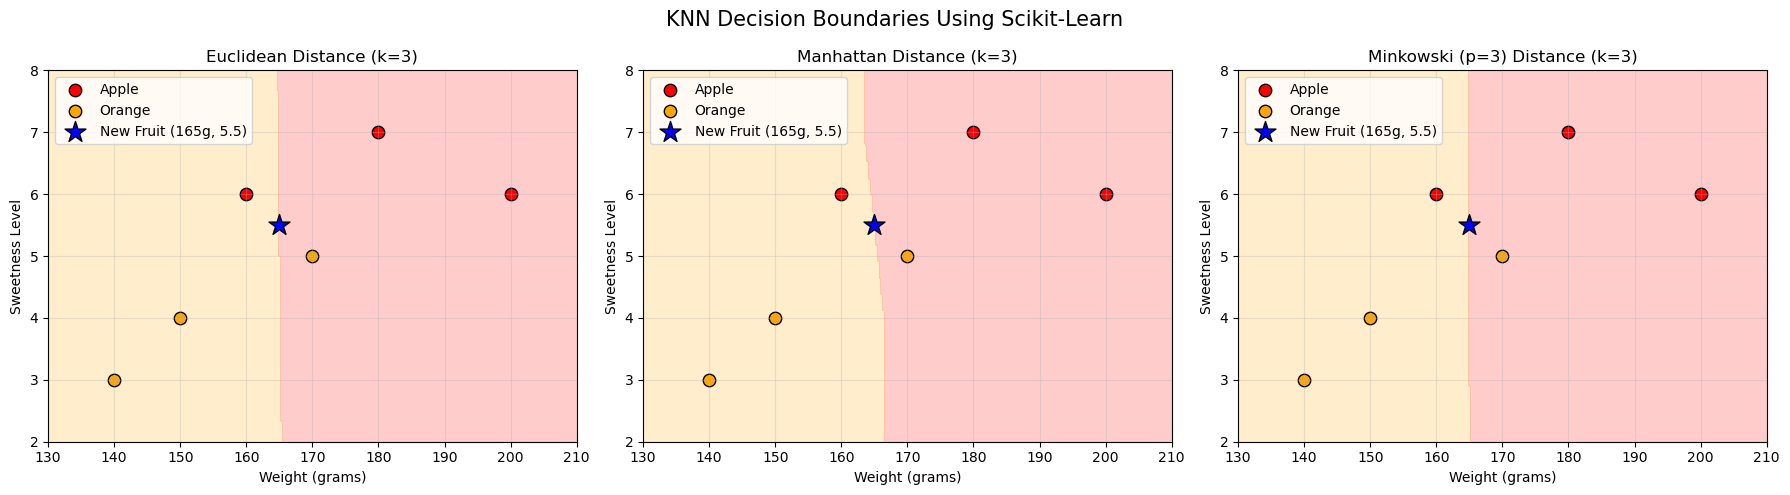

In [16]:
# =========================================================
# SCIKIT-LEARN KNN
# Euclidean, Manhattan and Minkowski Distance Comparison
# =========================================================




# ---------------------------------------------------------
# 1. Load the data
# ---------------------------------------------------------

weights = []
sweetness = []
labels = []

with open("fruits.csv", "r", newline="") as file:
    reader = csv.DictReader(file)

    for row in reader:
        weights.append(float(row["Weight (grams)"]))
        sweetness.append(float(row["Sweetness Level"]))
        labels.append(row["Label (Fruit Type)"].strip())

weights = np.array(weights)
sweetness = np.array(sweetness)
labels = np.array(labels)


# ---------------------------------------------------------
# 2. Prepare features and target
# ---------------------------------------------------------

X = np.column_stack((weights, sweetness))
y = labels

# New fruit to classify
new_fruit = np.array([[165, 5.5]])

# Number of neighbors
k = 3


# ---------------------------------------------------------
# 3. Define distance metrics
# ---------------------------------------------------------

metrics = [
    ("Euclidean", "euclidean"),
    ("Manhattan", "manhattan"),
    ("Minkowski (p=3)", "minkowski")
]


# ---------------------------------------------------------
# 4. Calculate distances and predictions
# ---------------------------------------------------------

print("SCIKIT-LEARN KNN DISTANCE COMPARISON")
print("=" * 60)

models = []

for name, metric in metrics:

    if metric == "minkowski":
        model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            p=3
        )
    else:
        model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

    # Train KNN
    model.fit(X, y)

    # Predict new fruit
    prediction = model.predict(new_fruit)[0]

    # Calculate distances to nearest neighbors
    distances, indices = model.kneighbors(new_fruit)

    models.append((name, model))

    print(f"\n{name}")
    print("-" * 60)

    print(f"Prediction: {prediction}")

    print("\nNearest Neighbors:")

    for rank, (distance, index) in enumerate(
        zip(distances[0], indices[0]),
        start=1
    ):
        print(
            f"{rank}. Fruit ID = {index + 1}, "
            f"Distance = {distance:.4f}, "
            f"Label = {labels[index]}"
        )


# ---------------------------------------------------------
# 5. Plot decision boundaries
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grid limits
weight_min = weights.min() - 10
weight_max = weights.max() + 10

sweet_min = sweetness.min() - 1
sweet_max = sweetness.max() + 1

# Create grid
xx, yy = np.meshgrid(
    np.linspace(weight_min, weight_max, 300),
    np.linspace(sweet_min, sweet_max, 300)
)

grid = np.column_stack(
    (xx.ravel(), yy.ravel())
)


# ---------------------------------------------------------
# 6. Draw each decision boundary
# ---------------------------------------------------------

for ax, (name, model) in zip(axes, models):

    # Predict class for every point in the grid
    Z = model.predict(grid)

    # Convert labels to numbers
    Z_numeric = np.where(Z == "Apple", 0, 1)

    Z_numeric = Z_numeric.reshape(xx.shape)

    # Decision regions
    ax.contourf(
        xx,
        yy,
        Z_numeric,
        levels=[-0.5, 0.5, 1.5],
        colors=["red", "orange"],
        alpha=0.20
    )

    # Apple samples
    apple_mask = labels == "Apple"

    ax.scatter(
        weights[apple_mask],
        sweetness[apple_mask],
        color="red",
        edgecolor="black",
        s=80,
        label="Apple"
    )

    # Orange samples
    orange_mask = labels == "Orange"

    ax.scatter(
        weights[orange_mask],
        sweetness[orange_mask],
        color="orange",
        edgecolor="black",
        s=80,
        label="Orange"
    )

    # New fruit
    ax.scatter(
        165,
        5.5,
        color="blue",
        marker="*",
        edgecolor="black",
        s=250,
        label="New Fruit (165g, 5.5)"
    )

    ax.set_xlabel("Weight (grams)")
    ax.set_ylabel("Sweetness Level")
    ax.set_title(f"{name} Distance (k={k})")
    ax.grid(alpha=0.3)
    ax.legend()


# Overall title
plt.suptitle(
    "KNN Decision Boundaries Using Scikit-Learn",
    fontsize=15
)

plt.tight_layout()
plt.show()


2A. 
<br>A Medical Diagnosis Decision
A dataset is provided to classify patients as "Healthy" or "Sick" based on their Age, Blood Pressure, and
Cholesterol levels.<br><br>
Tasks:<br>
<br>1. Calculate the entropy for the target variable (Diagnosis).
<br>2. Calculate the information gain for each feature (Age, Blood Pressure, Cholesterol).
<br>3. Using the ID3 algorithm, decide which feature should be chosen as the root node for the decision
tree.
<br>4. Build the decision tree and explain the first few splits.
<br>5. Predict whether a 50-year-old patient with low blood pressure and normal cholesterol is healthy or
sick using the tree you built.
<br>6. Implement the above using function python program without using scikit learn library.

In [21]:
def load_data(filename):

    data = []

    with open(filename, "r", newline="") as file:

        reader = csv.DictReader(file)

        for row in reader:

            data.append({
                "Age": int(row["Patient Age (years)"]),
                "Blood Pressure": row["Blood Pressure (High/Low)"].strip(),
                "Cholesterol": row["Cholesterol (High/Normal)"].strip(),
                "Diagnosis": row["Diagnosis (Healthy/Sick)"].strip()
            })

    return data


# =========================================================
# 2. CALCULATE ENTROPY
# =========================================================

def calculate_entropy(data):

    if len(data) == 0:
        return 0

    counts = {}

    for row in data:

        diagnosis = row["Diagnosis"]

        counts[diagnosis] = counts.get(diagnosis, 0) + 1

    total = len(data)

    entropy_value = 0

    for count in counts.values():

        probability = count / total

        entropy_value -= probability * math.log2(probability)

    return entropy_value


# =========================================================
# 3. GET UNIQUE VALUES OF A FEATURE
# =========================================================

def get_unique_values(data, feature):

    values = []

    for row in data:

        value = row[feature]

        if value not in values:
            values.append(value)

    return values


# =========================================================
# 4. SPLIT DATA
# =========================================================

def split_data(data, feature, value):

    subset = []

    for row in data:

        if row[feature] == value:
            subset.append(row)

    return subset


# =========================================================
# 5. CALCULATE INFORMATION GAIN
# =========================================================

def calculate_information_gain(data, feature):

    # Entropy before splitting
    total_entropy = calculate_entropy(data)

    # Get unique values
    values = get_unique_values(data, feature)

    weighted_entropy = 0

    for value in values:

        subset = split_data(
            data,
            feature,
            value
        )

        probability = len(subset) / len(data)

        subset_entropy = calculate_entropy(subset)

        weighted_entropy += (
            probability * subset_entropy
        )

    information_gain = (
        total_entropy - weighted_entropy
    )

    return information_gain


# =========================================================
# 6. FIND MAJORITY CLASS
# =========================================================

def majority_class(data):

    counts = {}

    for row in data:

        diagnosis = row["Diagnosis"]

        counts[diagnosis] = (
            counts.get(diagnosis, 0) + 1
        )

    return max(
        counts,
        key=counts.get
    )


# =========================================================
# 7. BUILD ID3 DECISION TREE
# =========================================================

def build_tree(data, features):
    diagnoses = [
        row["Diagnosis"]
        for row in data
    ]

    if len(set(diagnoses)) == 1:

        return diagnoses[0]

    if len(features) == 0:

        return majority_class(data)
    gains = {}

    for feature in features:

        gains[feature] = calculate_information_gain(
            data,
            feature
        )
    best_feature = max(
        gains,
        key=gains.get
    )

    tree = {
        best_feature: {}
    }
    values = get_unique_values(
        data,
        best_feature
    )
    remaining_features = [
        feature
        for feature in features
        if feature != best_feature
    ]
    for value in values:

        subset = split_data(
            data,
            best_feature,
            value
        )

        if len(subset) == 0:

            tree[best_feature][value] = (
                majority_class(data)
            )

        else:

            tree[best_feature][value] = build_tree(
                subset,
                remaining_features
            )

    return tree


# =========================================================
# 8. PRINT DECISION TREE
# =========================================================

def print_tree(tree, level=0):

    # If this is a leaf
    if not isinstance(tree, dict):

        print(
            " " * level +
            "-> " +
            str(tree)
        )

        return

    feature = list(tree.keys())[0]
    for value, subtree in tree[feature].items():

        print(" " * level +
            f"{feature} = {value}")

        print_tree(subtree,level + 4)


# =========================================================
# 9. PREDICT NEW PATIENT
# =========================================================

def predict(tree, patient):
    if not isinstance(tree, dict):

        return tree
    feature = list(tree.keys())[0]

    value = patient[feature]

    if value in tree[feature]:
        return predict(
            tree[feature][value],
            patient
        )
    return "Unknown"


# =========================================================
# 10. MAIN PROGRAM
# =========================================================

def main():

    data = load_data("patient.csv")
    features = [
        "Age",
        "Blood Pressure",
        "Cholesterol"
    ]
    #TASK1 entropy
    entropy = calculate_entropy(data)

    print("1. ENTROPY OF DIAGNOSIS")
    print("==========================================")

    print(
        f"Entropy(Diagnosis) = {entropy:.4f}"
    )


    # TASK 2: INFORMATION GAIN

    print("2. INFORMATION GAIN")
    print("==========================================")

    gains = {}

    for feature in features:

        gain = calculate_information_gain(
            data,
            feature
        )

        gains[feature] = gain

        print(
            f"{feature:<20} = {gain:.4f}"
        )


    # TASK 3: ROOT NODE

    root = max(
        gains,
        key=gains.get
    )

    print("3. ROOT NODE")
    print("==========================================")

    print(
        f"Root Node = {root}"
    )

    print(
        f"Highest Information Gain = "
        f"{gains[root]:.4f}"
    )


    # TASK 4: BUILD DECISION TREE

    tree = build_tree(
        data,
        features
    )

    print("4. ID3 DECISION TREE")
    print("==========================================")

    print_tree(tree)


    # TASK 5: PREDICT NEW PATIENT

    new_patient = {
        "Age": 50,
        "Blood Pressure": "Low",
        "Cholesterol": "Normal"
    }

    prediction = predict(
        tree,
        new_patient
    )

    print("5. NEW PATIENT PREDICTION")
    print("==========================================")

    print("Patient:")
    print("Age = 50")
    print("Blood Pressure = Low")
    print("Cholesterol = Normal")

    print(
        f"\nPredicted Diagnosis = {prediction}"
    )


# =========================================================
# RUN PROGRAM
# =========================================================

if __name__ == "__main__":
    main()


1. ENTROPY OF DIAGNOSIS
Entropy(Diagnosis) = 1.0000
2. INFORMATION GAIN
Age                  = 1.0000
Blood Pressure       = 1.0000
Cholesterol          = 1.0000
3. ROOT NODE
Root Node = Age
Highest Information Gain = 1.0000
4. ID3 DECISION TREE
Age = 30
    -> Sick
Age = 45
    -> Healthy
Age = 50
    -> Sick
Age = 35
    -> Healthy
Age = 60
    -> Sick
Age = 55
    -> Healthy
Age = 40
    -> Sick
Age = 25
    -> Healthy
Age = 65
    -> Sick
5. NEW PATIENT PREDICTION
Patient:
Age = 50
Blood Pressure = Low
Cholesterol = Normal

Predicted Diagnosis = Sick


2B.<br>
Implement the Python code for Q-2. A using the scikit-learn library. Using the ID3 algorithm, decide which
feature should be chosen as the root node for the decision tree. Build the decision tree and explain the first
few splits. Predict whether a 50-year-old patient with low blood pressure and normal cholesterol is healthy
or sick using the tree you built.

Dataset:


,ID,Patient Age (years),Blood Pressure (High/Low),Cholesterol (High/Normal),Diagnosis (Healthy/Sick)
0,1,30,High,High,Sick
1,2,45,Low,Normal,Healthy
2,3,50,High,High,Sick
3,4,35,Low,Normal,Healthy
4,5,60,High,High,Sick
5,6,55,Low,Normal,Healthy
6,7,40,High,High,Sick
7,8,25,Low,Normal,Healthy
8,9,65,High,High,Sick
9,10,45,Low,Normal,Healthy



ID3 DECISION TREE
Root Node = Blood Pressure

Information Gain / Feature Importance:
Age                  = 0.0000
Blood Pressure       = 1.0000
Cholesterol          = 0.0000

DECISION TREE STRUCTURE


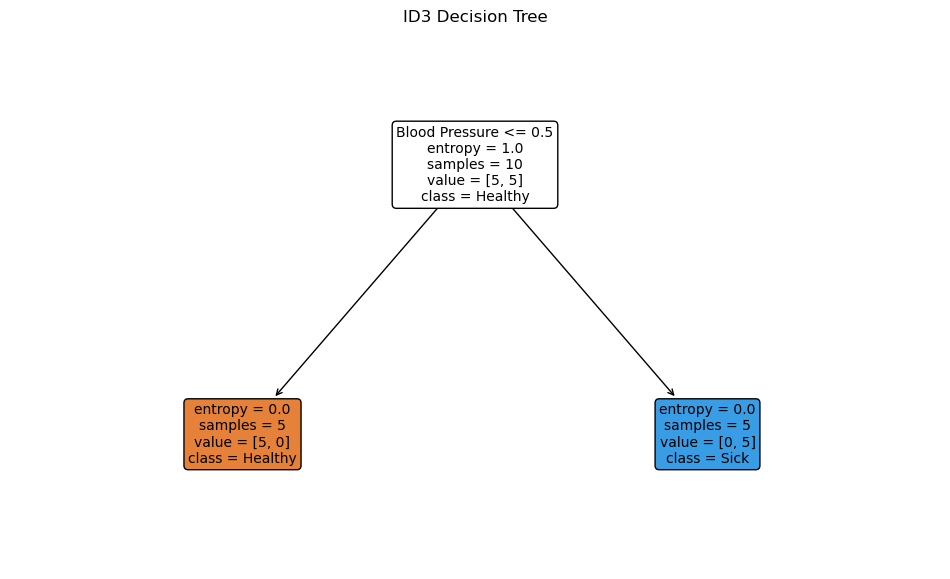

NEW PATIENT PREDICTION
Age = 50
Blood Pressure = Low
Cholesterol = Normal

Predicted Diagnosis = Healthy


In [24]:
df = pd.read_csv("patient.csv")

print("Dataset:")
display(df)

# ---------------------------------------------------------
# 2. Prepare the features
# ---------------------------------------------------------

df["Blood Pressure"] = df["Blood Pressure (High/Low)"].map({
    "Low": 0,
    "High": 1
})
df["Cholesterol"] = df["Cholesterol (High/Normal)"].map({
    "Normal": 0,
    "High": 1
})
df["Age"] = df["Patient Age (years)"]
df["Diagnosis"] = df["Diagnosis (Healthy/Sick)"].map({
    "Healthy": 0,
    "Sick": 1
})


# ---------------------------------------------------------
# 3. Select features and target
# ---------------------------------------------------------

X = df[
    ["Age", "Blood Pressure", "Cholesterol"]
]

y = df["Diagnosis"]


# ---------------------------------------------------------
# 4. Build ID3 Decision Tree
# ---------------------------------------------------------

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X, y)


# ---------------------------------------------------------
# 5. Find the root node
# ---------------------------------------------------------

feature_names = [
    "Age",
    "Blood Pressure",
    "Cholesterol"
]

root_index = model.tree_.feature[0]

root_feature = feature_names[root_index]

print("\n==========================================")
print("ID3 DECISION TREE")
print("==========================================")

print(f"Root Node = {root_feature}")


# ---------------------------------------------------------
# 6. Display Information Gain
# ---------------------------------------------------------

print("\nInformation Gain / Feature Importance:")

for feature, importance in zip(
    feature_names,
    model.feature_importances_
):
    print(
        f"{feature:<20} = {importance:.4f}"
    )


# ---------------------------------------------------------
# 7. Print the decision tree
# ---------------------------------------------------------

print("\n==========================================")
print("DECISION TREE STRUCTURE")
print("==========================================")

plt.figure(figsize=(12, 7))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=["Healthy", "Sick"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("ID3 Decision Tree")
plt.show()


# ---------------------------------------------------------
# 8. Predict the new patient
# ---------------------------------------------------------

new_patient = pd.DataFrame({
    "Age": [50],
    "Blood Pressure": [0],   # Low
    "Cholesterol": [0]       # Normal
})

prediction = model.predict(new_patient)[0]

if prediction == 0:
    diagnosis = "Healthy"
else:
    diagnosis = "Sick"



print("NEW PATIENT PREDICTION")
print("==========================================")

print("Age = 50")
print("Blood Pressure = Low")
print("Cholesterol = Normal")

print(f"\nPredicted Diagnosis = {diagnosis}")


# ADDITIONAL

1.
<br>
We have data from the questionnaires survey (to ask people opinion) and objective testing with two
attributes (acid durability and strength) to classify whether a special paper tissue is good or not. Here is four
training samples as follows. Apply the K-nearest neighbour’s (KNN) algorithm when K=2, 3 and 4 to classify
an instance (3, 7) as good or bad.
<br>
Implement the above using python code without using scikit learn library. Plot the given samples Bad in Red
color and Good in green color. Also draw the decision boundary. Calculate the desistance using Euclidean,
Manhattan, and Minkowski and compare.

In [28]:
# X1 = Acid Durability (seconds)
# X2 = Strength (kg/square meter)

X = np.array([
    [7, 7],
    [7, 4],
    [3, 4],
    [1, 4],
    [4, 5],
    [3, 5],
    [4, 6],
    [8, 7],
    [7, 9],
    [8, 8]
])

Y = np.array([
    "Bad",
    "Bad",
    "Good",
    "Good",
    "Bad",
    "Good",
    "Bad",
    "Bad",
    "Good",
    "Bad"
])

new_instance = np.array([3, 7])


# =========================================================
# 2. DISTANCE FUNCTIONS
# =========================================================

def euclidean_distance(point1, point2):
    return math.sqrt(
        (point1[0] - point2[0]) ** 2 +
        (point1[1] - point2[1]) ** 2
    )


def manhattan_distance(point1, point2):
    return (
        abs(point1[0] - point2[0]) +
        abs(point1[1] - point2[1])
    )


def minkowski_distance(point1, point2, p=3):
    return (
        abs(point1[0] - point2[0]) ** p +
        abs(point1[1] - point2[1]) ** p
    ) ** (1 / p)


# =========================================================
# 3. CALCULATE ALL DISTANCES
# =========================================================

def calculate_distances(X, Y, new_instance):

    results = []

    for i in range(len(X)):

        euclidean = euclidean_distance(
            new_instance,
            X[i]
        )

        manhattan = manhattan_distance(
            new_instance,
            X[i]
        )

        minkowski = minkowski_distance(
            new_instance,
            X[i],
            p=3
        )

        results.append({
            "id": i + 1,
            "x1": X[i][0],
            "x2": X[i][1],
            "label": Y[i],
            "euclidean": euclidean,
            "manhattan": manhattan,
            "minkowski": minkowski
        })

    return results


# =========================================================
# 4. PRINT DISTANCE TABLE
# =========================================================

def print_distance_table(results):

    print("\nDISTANCES FROM NEW INSTANCE (3, 7)")
    print("=" * 95)

    print(
        f"{'ID':<5}"
        f"{'Acid':<10}"
        f"{'Strength':<12}"
        f"{'Class':<10}"
        f"{'Euclidean':<15}"
        f"{'Manhattan':<15}"
        f"{'Minkowski(p=3)':<18}"
    )

    print("-" * 95)

    for r in results:

        print(
            f"{r['id']:<5}"
            f"{r['x1']:<10}"
            f"{r['x2']:<12}"
            f"{r['label']:<10}"
            f"{r['euclidean']:<15.4f}"
            f"{r['manhattan']:<15.4f}"
            f"{r['minkowski']:<18.4f}"
        )


# =========================================================
# 5. KNN PREDICTION
# =========================================================

def knn_predict(X, Y, new_instance, k, metric):

    distances = []

    for i in range(len(X)):

        if metric == "euclidean":

            distance = euclidean_distance(
                new_instance,
                X[i]
            )

        elif metric == "manhattan":

            distance = manhattan_distance(
                new_instance,
                X[i]
            )

        elif metric == "minkowski":

            distance = minkowski_distance(
                new_instance,
                X[i],
                p=3
            )

        distances.append(
            (distance, Y[i], i)
        )

    distances.sort(
        key=lambda x: x[0]
    )

    neighbors = distances[:k]
    votes = {}

    for distance, label, index in neighbors:

        votes[label] = votes.get(label,0) + 1

    prediction = max(
        votes,
        key=votes.get
    )

    return prediction, neighbors, votes


# =========================================================
# 6. MAIN DISTANCE COMPARISON
# =========================================================

results = calculate_distances(
    X,
    Y,
    new_instance
)

print_distance_table(results)


# =========================================================
# 7. COMPARE K = 2, 3, 4
# =========================================================

metrics = [
    ("Euclidean", "euclidean"),
    ("Manhattan", "manhattan"),
    ("Minkowski (p=3)", "minkowski")
]

for metric_name, metric in metrics:

    print("\n")
    print("=" * 70)
    print(f"{metric_name.upper()} DISTANCE")
    print("=" * 70)

    for k in [2, 3, 4]:

        prediction, neighbors, votes = knn_predict(
            X,
            Y,
            new_instance,
            k,
            metric
        )

        print(f"\nK = {k}")
        print(f"Prediction = {prediction}")
        print(f"Votes = {votes}")

        print("Nearest Neighbors:")

        for rank, (distance, label, index) in enumerate(
            neighbors,
            start=1
        ):

            print(
                f"  {rank}. "
                f"ID = {index + 1}, "
                f"Point = ({X[index][0]}, {X[index][1]}), "
                f"Distance = {distance:.4f}, "
                f"Class = {label}"
            )


# =========================================================
# 8. DECISION BOUNDARY
# =========================================================

def plot_decision_boundary(
    X,
    Y,
    k=3,
    metric="euclidean"
):

    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = []

    for y_value in np.linspace(
        y_min,
        y_max,
        300
    ):

        row = []

        for x_value in np.linspace(
            x_min,
            x_max,
            300
        ):

            point = np.array([
                x_value,
                y_value
            ])

            prediction, _, _ = knn_predict(
                X,
                Y,
                point,
                k,
                metric
            )

            if prediction == "Good":
                row.append(1)
            else:
                row.append(0)

        Z.append(row)

    Z = np.array(Z)

    plt.contourf(
        xx,
        yy,
        Z,
        levels=[-0.5, 0.5, 1.5],
        colors=["red", "green"],
        alpha=0.20
    )

    # Plot Bad samples
    bad_mask = Y == "Bad"

    plt.scatter(
        X[bad_mask, 0],
        X[bad_mask, 1],
        color="red",
        edgecolor="black",
        s=100,
        label="Bad"
    )

    # Plot Good samples
    good_mask = Y == "Good"

    plt.scatter(
        X[good_mask, 0],
        X[good_mask, 1],
        color="green",
        edgecolor="black",
        s=100,
        label="Good"
    )

    # Plot new instance
    plt.scatter(
        new_instance[0],
        new_instance[1],
        color="blue",
        marker="*",
        edgecolor="black",
        s=300,
        label="New Instance (3, 7)"
    )

    plt.xlabel("Acid Durability (seconds)")
    plt.ylabel("Strength (kg/square meter)")

    plt.title(
        f"KNN Decision Boundary - "
        f"{metric.title()} Distance (K={k})"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()






DISTANCES FROM NEW INSTANCE (3, 7)
ID   Acid      Strength    Class     Euclidean      Manhattan      Minkowski(p=3)    
-----------------------------------------------------------------------------------------------
1    7         7           Bad       4.0000         4.0000         4.0000            
2    7         4           Bad       5.0000         7.0000         4.4979            
3    3         4           Good      3.0000         3.0000         3.0000            
4    1         4           Good      3.6056         5.0000         3.2711            
5    4         5           Bad       2.2361         3.0000         2.0801            
6    3         5           Good      2.0000         2.0000         2.0000            
7    4         6           Bad       1.4142         2.0000         1.2599            
8    8         7           Bad       5.0000         5.0000         5.0000            
9    7         9           Good      4.4721         6.0000         4.1602            
10   8  

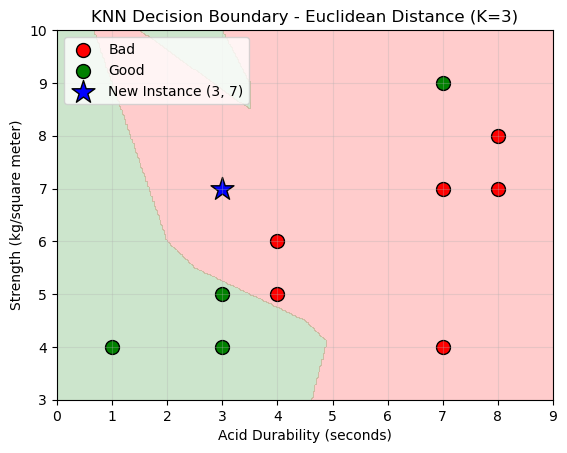

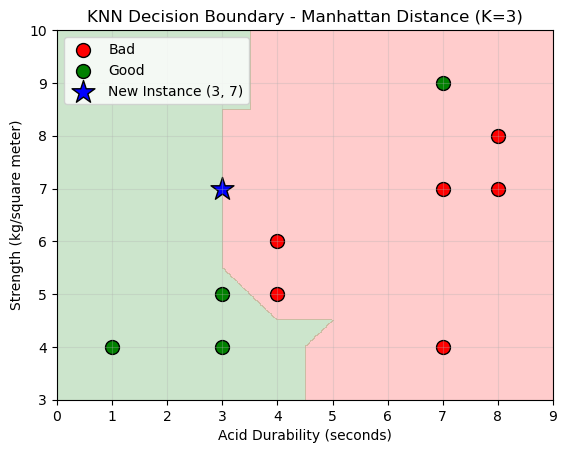

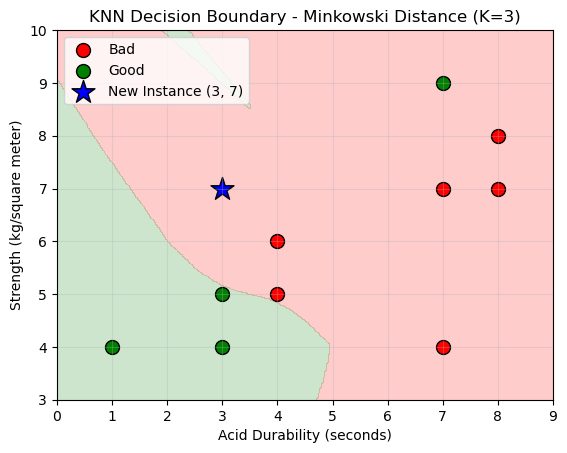

In [29]:
plot_decision_boundary(
    X,
    Y,
    k=3,
    metric="euclidean"
)

plot_decision_boundary(
    X,
    Y,
    k=3,
    metric="manhattan"
)

plot_decision_boundary(
    X,
    Y,
    k=3,
    metric="minkowski"
)